In [59]:
import cv2

import numpy as np
import matplotlib.pyplot as plt

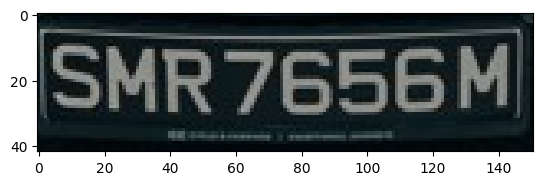

In [72]:
template = cv2.imread('images/template1.jpg')
template.shape

# template_resized = cv2.resize(template, (150, int(150/template.shape[1]*template.shape[0])))
# print(template_resized.shape)

tpl = template.copy()
plt.imshow(cv2.cvtColor(tpl, cv2.COLOR_BGR2RGB))

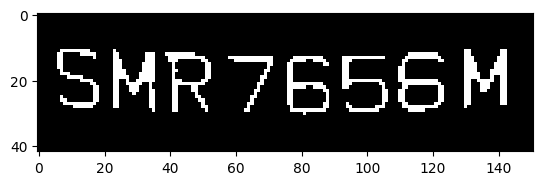

In [73]:
gray = cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY)
binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)[1]
kernel = np.ones((2, 2), np.uint8)
binary = cv2.erode(binary, kernel, iterations=1)
# binary = cv2.dilate(eroded, kernel, iterations=2)

plt.imshow(binary,cmap='grey')

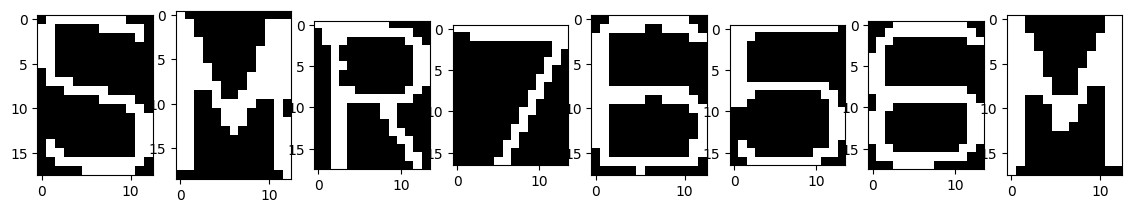

In [76]:
import matplotlib.gridspec as gridspec

cont, _  = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont = sorted(cont, key=lambda c: cv2.boundingRect(c)[0])

fig = plt.figure(figsize=(14,4))
grid = gridspec.GridSpec(ncols=len(cont),nrows=1,figure=fig)

for i, c in enumerate(cont):
    (x, y, w, h) = cv2.boundingRect(c)
    ratio = h/w
    if 1<=ratio<=2:
        fig.add_subplot(grid[0, i])
        plt.imshow(binary[y:y+h, x:x+w], cmap='gray')

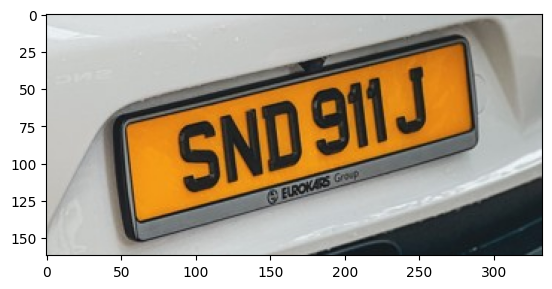

In [77]:
template = cv2.imread('images/template2.jpg')
template.shape

# template_resized = cv2.resize(template, (150, int(150/template.shape[1]*template.shape[0])))
# print(template_resized.shape)

tpl = template.copy()
plt.imshow(cv2.cvtColor(tpl, cv2.COLOR_BGR2RGB))

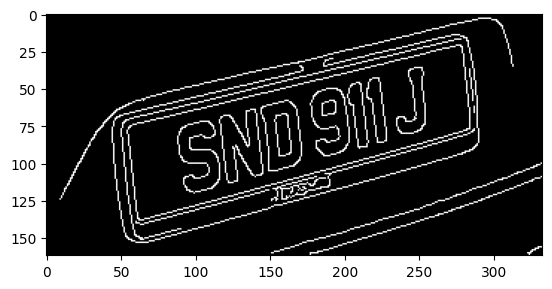

In [81]:
gray = cv2.cvtColor(tpl, cv2.COLOR_BGR2GRAY)
gray = cv2.GaussianBlur(gray, (5, 5), 0)
edged = cv2.Canny(gray, 75, 200)

plt.imshow(cv2.cvtColor(edged, cv2.COLOR_BGR2RGB))

In [97]:
cnts,_ = cv2.findContours(edged.copy(), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
quads = []


for c in cnts:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        quads.append(approx)


In [101]:
len(quads)

2

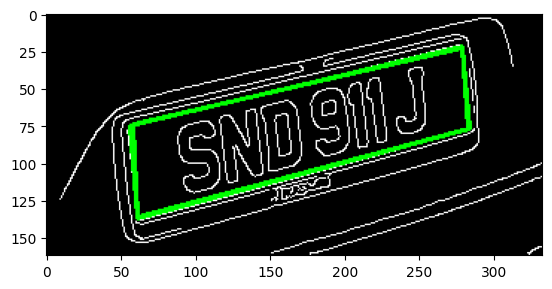

In [100]:
dbg = cv2.cvtColor(edged, cv2.COLOR_GRAY2BGR)
cv2.drawContours(dbg, quads, -1, (0,255,0), 2)
plt.imshow(cv2.cvtColor(dbg, cv2.COLOR_BGR2RGB))

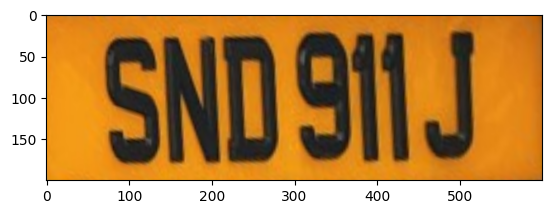

In [125]:
def order_quad_points(pts):
    """
    pts: (4, 1, 2) or (4, 2) array of quad points
    returns: (4, 2) ordered as
             [top-left, top-right, bottom-right, bottom-left]
    """
    pts = np.squeeze(pts).astype(np.float32)  # ensure shape (4,2)

    s = pts.sum(axis=1)        # x + y
    diff = np.diff(pts, axis=1)  # x - y

    tl = pts[np.argmin(s)]
    br = pts[np.argmax(s)]
    tr = pts[np.argmin(diff)]
    bl = pts[np.argmax(diff)]

    return np.array([tl, tr, br, bl], dtype=np.float32)


quad = order_quad_points(quads[0])

src = np.float32(quad)

# output rectangle size
W, H = 600, 200

dst = np.float32([
    [0,   0],
    [W-1, 0],
    [W-1, H-1],
    [0,   H-1]
])

M = cv2.getPerspectiveTransform(src, dst)   # 3x3 homography
warped = cv2.warpPerspective(tpl, M, (W, H))

plt.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB))

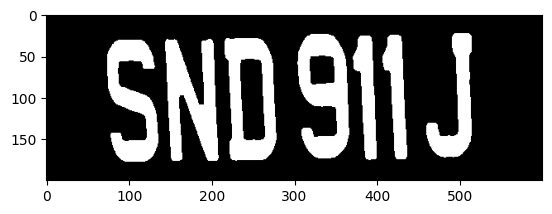

In [130]:
gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
binary = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY_INV)[1]
# kernel = np.ones((2, 2), np.uint8)
# binary = cv2.erode(binary, kernel, iterations=1)
# binary = cv2.dilate(eroded, kernel, iterations=2)
kernel = np.ones((3, 3), np.uint8)
binary = cv2.erode(binary, kernel, iterations=2)

plt.imshow(binary,cmap='grey')

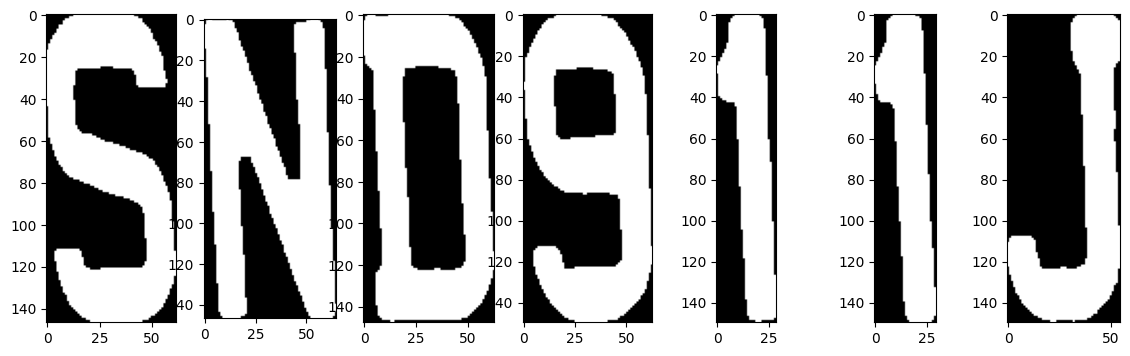

In [131]:
cont, _  = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cont = sorted(cont, key=lambda c: cv2.boundingRect(c)[0])

fig = plt.figure(figsize=(14,4))
grid = gridspec.GridSpec(ncols=len(cont),nrows=1,figure=fig)

for i, c in enumerate(cont):
    (x, y, w, h) = cv2.boundingRect(c)
    fig.add_subplot(grid[0, i])
    plt.imshow(binary[y:y+h, x:x+w], cmap='gray')